<cell_type>markdown</cell_type>## Overview

**Sensitivity analysis** helps you understand which layers in your model are:
- **Fragile** (sensitive): Large accuracy drop when compressed
- **Robust** (compressible): Minimal accuracy impact when compressed

This enables **non-uniform compression**: aggressive compression on robust layers, conservative on fragile ones.

The sensitivity module integrates with **fasterai** for:
- Using the same compression criteria (`large_final`, `movement`, etc.)
- True structural pruning via `Pruner`
- Consistent sparsity application via `Sparsifier`

This tutorial covers:
1. Basic sensitivity analysis
2. Different compression types (sparsity, pruning, quantization)
3. Analyzing and visualizing results
4. Generating non-uniform compression schedules
5. Multi-level sensitivity sweeps
6. Using different fasterai criteria

## Setup

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

from fasterbench import SensitivityAnalyzer, analyze_sensitivity
from fasterai.core.all import large_final, movement  # fasterai criteria

### Prepare Model and Data

We'll use a pretrained ResNet-18 and CIFAR-10 for this tutorial.

In [ ]:
from fastai.vision.all import *
from fasterai.distill.all import *

model = resnet18()
path = untar_data(URLs.PETS)
files = get_image_files(path/"images")

def label_func(f): return f[0].isupper()

dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(64))
sample_input = torch.Tensor(dls.one_batch()[0][0][None]).cpu()

learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.unfreeze()
learn.fit(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.533339,0.777861,0.790934,00:03
1,0.337178,0.393662,0.850474,00:03
2,0.256941,0.369752,0.824087,00:03


### Define Evaluation Function

The key to using `SensitivityAnalyzer` is providing an evaluation function that:
- Takes a model as input
- Returns a single metric value (higher = better by default)

In [ ]:
def eval_accuracy(model, max_batches=20):
    """Compute accuracy on validation set."""
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for i, (x, y) in enumerate(dls.valid):
            if i >= max_batches:
                break
            outputs = model(x)
            correct += (outputs.argmax(1) == y).sum().item()
            total += len(y)
    
    return correct / total

# Test it
baseline = eval_accuracy(learn.model)
print(f"Baseline accuracy: {baseline:.4f}")

Baseline accuracy: 0.8195


```
Baseline accuracy: 0.8234
```

## 1. Basic Sensitivity Analysis

The simplest way to run sensitivity analysis:

In [ ]:
# One-liner: analyze sparsity sensitivity at 50%
result = analyze_sensitivity(learn.model, sample_input, eval_accuracy, "sparsity", level=50)

Computing baseline accuracy... 0.8195
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0094
  [2/22] 0.4.0.conv1... Δ=-0.0039
  [3/22] 0.4.0.conv2... Δ=-0.0031
  [4/22] 0.4.1.conv1... Δ=+0.0023
  [5/22] 0.4.1.conv2... Δ=+0.0078
  [6/22] 0.5.0.conv1... Δ=-0.0078
  [7/22] 0.5.0.conv2... Δ=+0.0031
  [8/22] 0.5.0.downsample.0... Δ=-0.0109
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=+0.0039
  [11/22] 0.6.0.conv1... Δ=+0.0031
  [12/22] 0.6.0.conv2... Δ=-0.0023
  [13/22] 0.6.0.downsample.0... Δ=-0.0016
  [14/22] 0.6.1.conv1... Δ=-0.0016
  [15/22] 0.6.1.conv2... Δ=+0.0008
  [16/22] 0.7.0.conv1... Δ=+0.0008
  [17/22] 0.7.0.conv2... Δ=+0.0008
  [18/22] 0.7.0.downsample.0... Δ=-0.0008
  [19/22] 0.7.1.conv1... Δ=+0.0008
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0008
  [22/22] 1.8... Δ=+0.0008
✓ Analysis complete


```
Computing baseline accuracy... 0.8234
Analyzing 21 layers for sparsity sensitivity @ 50%
  [1/21] conv1... Δ=+0.1523
  [2/21] layer1.0.conv1... Δ=+0.0892
  [3/21] layer1.0.conv2... Δ=+0.0156
  [4/21] layer1.1.conv1... Δ=+0.0078
  ...
  [21/21] fc... Δ=+0.0234
✓ Analysis complete
```

### View Results Summary

In [ ]:
result.summary()

════════════════════════════════════════════════════════════
Sensitivity Analysis: sparsity @ 50%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.8195
  Layers analyzed: 22

  🔴 Most Sensitive (fragile):
     1. 0.0                            Δ=+0.0094
     2. 0.4.1.conv2                    Δ=+0.0078
     3. 0.5.1.conv2                    Δ=+0.0039
     4. 0.5.0.conv2                    Δ=+0.0031
     5. 0.6.0.conv1                    Δ=+0.0031

  🟢 Most Robust (compressible):
     1. 0.5.0.downsample.0             Δ=-0.0109
     2. 0.5.0.conv1                    Δ=-0.0078
     3. 0.4.0.conv1                    Δ=-0.0039
     4. 0.4.0.conv2                    Δ=-0.0031
     5. 0.6.0.conv2                    Δ=-0.0023


```
════════════════════════════════════════════════════════════
Sensitivity Analysis: sparsity @ 50.0%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.8234
  Layers analyzed: 21

  🔴 Most Sensitive (fragile):
     1. conv1                          Δ=+0.1523
     2. layer1.0.conv1                 Δ=+0.0892
     3. layer2.0.conv1                 Δ=+0.0731
     4. layer2.0.conv2                 Δ=+0.0704
     5. layer2.1.conv2                 Δ=+0.0507

  🟢 Most Robust (compressible):
     1. layer3.0.downsample.0          Δ=-0.0108
     2. layer2.1.conv1                 Δ=-0.0054
     3. layer1.1.conv1                 Δ=+0.0061
     4. layer2.0.downsample.0          Δ=+0.0068
     5. layer3.1.conv2                 Δ=+0.0074
```

### Using the Full Analyzer Class

For more control, use `SensitivityAnalyzer` directly:

In [ ]:
analyzer = SensitivityAnalyzer(
    learn.model,
    sample_input,              # example input for Pruner dependency analysis
    eval_accuracy,
    criteria=large_final,      # fasterai criteria (magnitude-based)
    metric_name="accuracy",
    higher_is_better=True,     # accuracy: higher is better
)

result = analyzer.analyze(
    compression="sparsity",
    level=50,
    granularity="weight",      # unstructured sparsity
    verbose=True,
)

Computing baseline accuracy... 0.8195
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0094
  [2/22] 0.4.0.conv1... Δ=-0.0039
  [3/22] 0.4.0.conv2... Δ=-0.0031
  [4/22] 0.4.1.conv1... Δ=+0.0023
  [5/22] 0.4.1.conv2... Δ=+0.0078
  [6/22] 0.5.0.conv1... Δ=-0.0078
  [7/22] 0.5.0.conv2... Δ=+0.0031
  [8/22] 0.5.0.downsample.0... Δ=-0.0109
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=+0.0039
  [11/22] 0.6.0.conv1... Δ=+0.0031
  [12/22] 0.6.0.conv2... Δ=-0.0023
  [13/22] 0.6.0.downsample.0... Δ=-0.0016
  [14/22] 0.6.1.conv1... Δ=-0.0016
  [15/22] 0.6.1.conv2... Δ=+0.0008
  [16/22] 0.7.0.conv1... Δ=+0.0008
  [17/22] 0.7.0.conv2... Δ=+0.0008
  [18/22] 0.7.0.downsample.0... Δ=-0.0008
  [19/22] 0.7.1.conv1... Δ=+0.0008
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0008
  [22/22] 1.8... Δ=+0.0008
✓ Analysis complete


## 2. Different Compression Types

The analyzer supports three compression methods:

### Sparsity (Unstructured)

Zeros out individual weights by magnitude:

In [ ]:
result_sparsity = analyzer.analyze("sparsity", level=50, granularity="weight")

Computing baseline accuracy... 0.8195
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0094
  [2/22] 0.4.0.conv1... Δ=-0.0039
  [3/22] 0.4.0.conv2... Δ=-0.0031
  [4/22] 0.4.1.conv1... Δ=+0.0023
  [5/22] 0.4.1.conv2... Δ=+0.0078
  [6/22] 0.5.0.conv1... Δ=-0.0078
  [7/22] 0.5.0.conv2... Δ=+0.0031
  [8/22] 0.5.0.downsample.0... Δ=-0.0109
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=+0.0039
  [11/22] 0.6.0.conv1... Δ=+0.0031
  [12/22] 0.6.0.conv2... Δ=-0.0023
  [13/22] 0.6.0.downsample.0... Δ=-0.0016
  [14/22] 0.6.1.conv1... Δ=-0.0016
  [15/22] 0.6.1.conv2... Δ=+0.0008
  [16/22] 0.7.0.conv1... Δ=+0.0008
  [17/22] 0.7.0.conv2... Δ=+0.0008
  [18/22] 0.7.0.downsample.0... Δ=-0.0008
  [19/22] 0.7.1.conv1... Δ=+0.0008
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0008
  [22/22] 1.8... Δ=+0.0008
✓ Analysis complete


<cell_type>markdown</cell_type>### Pruning (Structural)

Uses fasterai's `Pruner` for true structural pruning - actually removes filters/channels:

In [ ]:
result_pruning = analyzer.analyze("pruning", level=30)

Computing baseline accuracy... 0.8195
Analyzing 22 layers for pruning @ 30% (structural, criteria=abs)
  [1/22] 0.0... Δ=0.0000
  [2/22] 0.4.0.conv1... Δ=+0.0078
  [3/22] 0.4.0.conv2... Δ=0.0000
  [4/22] 0.4.1.conv1... Δ=+0.0227
  [5/22] 0.4.1.conv2... Δ=0.0000
  [6/22] 0.5.0.conv1... Δ=-0.0172
  [7/22] 0.5.0.conv2... Δ=0.0000
  [8/22] 0.5.0.downsample.0... Δ=0.0000
  [9/22] 0.5.1.conv1... Δ=+0.0102
  [10/22] 0.5.1.conv2... Δ=0.0000
  [11/22] 0.6.0.conv1... Δ=-0.0039
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=+0.0008
  [15/22] 0.6.1.conv2... Δ=0.0000
  [16/22] 0.7.0.conv1... Δ=+0.0039
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0070
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0008
  [22/22] 1.8... Δ=+0.1352
✓ Analysis complete


### Quantization

Simulates INT8 quantization per layer:

In [ ]:
result_quant = analyzer.analyze("quantization", level=8)  # 8-bit

Computing baseline accuracy... 0.8195
Analyzing 22 layers for quantization @ 8bits (per-channel, weights only)
  [1/22] 0.0... Δ=0.0000
  [2/22] 0.4.0.conv1... Δ=0.0000
  [3/22] 0.4.0.conv2... Δ=0.0000
  [4/22] 0.4.1.conv1... Δ=0.0000
  [5/22] 0.4.1.conv2... Δ=0.0000
  [6/22] 0.5.0.conv1... Δ=0.0000
  [7/22] 0.5.0.conv2... Δ=0.0000
  [8/22] 0.5.0.downsample.0... Δ=0.0000
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=0.0000
  [11/22] 0.6.0.conv1... Δ=0.0000
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=0.0000
  [15/22] 0.6.1.conv2... Δ=0.0000
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=0.0000
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=0.0000
  [22/22] 1.8... Δ=0.0000
✓ Analysis complete


## 3. Analyzing Results

### Top Layers

In [ ]:
# Most sensitive (fragile) - should NOT compress aggressively
fragile = result.top(5, most_sensitive=True)
print("🔴 Fragile layers (protect these):")
for layer in fragile:
    print(f"   {layer.name}: Δ={layer.delta:+.4f}")

print()

# Most robust - CAN compress aggressively
robust = result.top(5, most_sensitive=False)
print("🟢 Robust layers (compress these):")
for layer in robust:
    print(f"   {layer.name}: Δ={layer.delta:+.4f}")

🔴 Fragile layers (protect these):
   0.0: Δ=+0.0094
   0.4.1.conv2: Δ=+0.0078
   0.5.1.conv2: Δ=+0.0039
   0.5.0.conv2: Δ=+0.0031
   0.6.0.conv1: Δ=+0.0031

🟢 Robust layers (compress these):
   0.5.0.downsample.0: Δ=-0.0109
   0.5.0.conv1: Δ=-0.0078
   0.4.0.conv1: Δ=-0.0039
   0.4.0.conv2: Δ=-0.0031
   0.6.0.conv2: Δ=-0.0023


```
🔴 Fragile layers (protect these):
   conv1: Δ=+0.1523
   layer1.0.conv1: Δ=+0.0892
   layer2.0.conv1: Δ=+0.0731
   layer2.0.conv2: Δ=+0.0704
   layer2.1.conv2: Δ=+0.0507

🟢 Robust layers (compress these):
   layer3.0.downsample.0: Δ=-0.0108
   layer2.1.conv1: Δ=-0.0054
   layer1.1.conv1: Δ=+0.0061
   layer2.0.downsample.0: Δ=+0.0068
   layer3.1.conv2: Δ=+0.0074
```

### Convert to DataFrame

In [ ]:
df = result.to_dataframe()
print(df[['name', 'layer_type', 'params', 'delta']].head(10))

                 name layer_type  params     delta
0                 0.0     Conv2d    9408  0.009375
1         0.4.0.conv1     Conv2d   36864 -0.003906
2         0.4.0.conv2     Conv2d   36864 -0.003125
3         0.4.1.conv1     Conv2d   36864  0.002344
4         0.4.1.conv2     Conv2d   36864  0.007812
5         0.5.0.conv1     Conv2d   73728 -0.007812
6         0.5.0.conv2     Conv2d  147456  0.003125
7  0.5.0.downsample.0     Conv2d    8192 -0.010937
8         0.5.1.conv1     Conv2d  147456  0.000000
9         0.5.1.conv2     Conv2d  147456  0.003906


```
                    name layer_type  params    delta
0                  conv1     Conv2d    9408   0.1523
1       layer1.0.conv1     Conv2d   36864   0.0892
2       layer1.0.conv2     Conv2d   36864   0.0156
3       layer1.1.conv1     Conv2d   36864   0.0061
4       layer1.1.conv2     Conv2d   36864   0.0217
5       layer2.0.conv1     Conv2d   73728   0.0731
6       layer2.0.conv2     Conv2d  147456   0.0704
7  layer2.0.downsample.0  Conv2d    8192   0.0068
8       layer2.1.conv1     Conv2d  147456  -0.0054
9       layer2.1.conv2     Conv2d  147456   0.0507
```

### Visualization

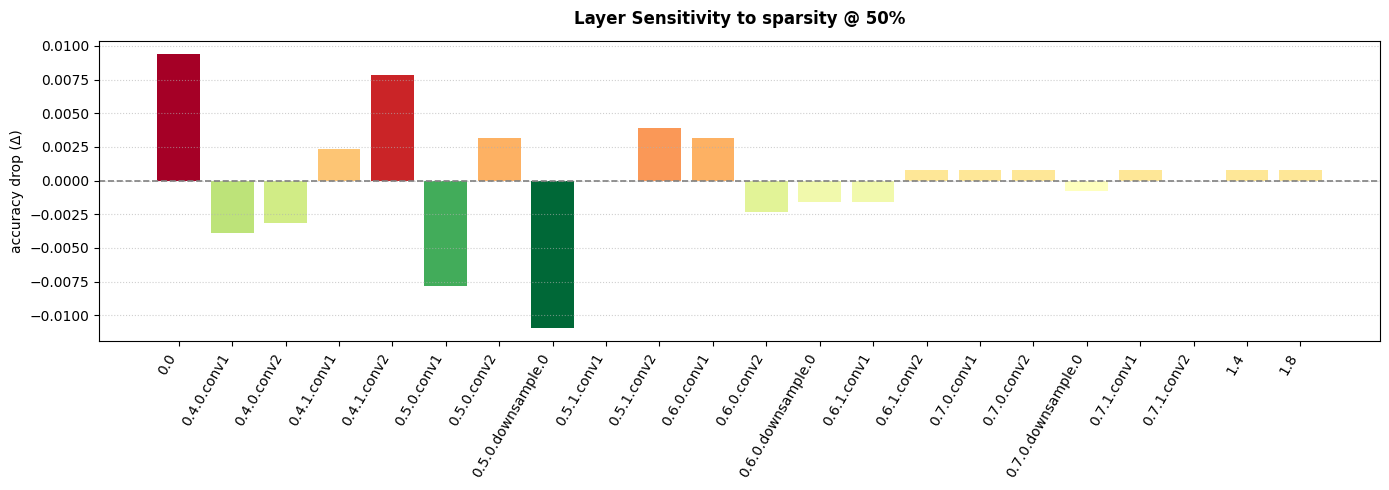

In [ ]:
result.plot(figsize=(14, 5))

This creates a bar chart with:
- **Red bars**: Sensitive layers (high accuracy drop)
- **Green bars**: Robust layers (low/negative accuracy drop)

## 4. Non-Uniform Compression Schedules

The killer feature: convert sensitivity results into a per-layer compression schedule.

**Key insight**: Instead of applying 50% sparsity uniformly, we can:
- Apply 10-20% to fragile layers (protecting accuracy)
- Apply 70-90% to robust layers (maximizing compression)
- Still achieve 50% *overall* sparsity!

In [ ]:
schedule = result.to_schedule(
    learn.model,
    target_pct=50,    # Target 50% overall sparsity
    min_pct=5,        # No layer below 5%
    max_pct=90,       # No layer above 90%
    gamma=1.5,        # Higher = more differentiation
)

# View the schedule
print("Per-layer sparsity schedule:")
for name, sparsity in list(schedule.items())[:22]:
    print(f"  {name:30} {sparsity:5.1f}%")

Per-layer sparsity schedule:
  0.0                              5.0%
  0.4.0.conv1                     58.6%
  0.4.0.conv2                     58.6%
  0.4.1.conv1                     28.8%
  0.4.1.conv2                      5.0%
  0.5.0.conv1                     58.6%
  0.5.0.conv2                     19.9%
  0.5.0.downsample.0              58.6%
  0.5.1.conv1                     58.6%
  0.5.1.conv2                     11.5%
  0.6.0.conv1                     19.9%
  0.6.0.conv2                     58.6%
  0.6.0.downsample.0              58.6%
  0.6.1.conv1                     58.6%
  0.6.1.conv2                     48.2%
  0.7.0.conv1                     48.2%
  0.7.0.conv2                     48.2%
  0.7.0.downsample.0              58.6%
  0.7.1.conv1                     48.2%
  0.7.1.conv2                     58.6%
  1.4                             48.2%
  1.8                             48.2%


```
Per-layer sparsity schedule:
  conv1                          5.0%
  layer1.0.conv1                12.3%
  layer1.0.conv2                58.2%
  layer1.1.conv1                64.7%
  layer1.1.conv2                51.4%
  layer2.0.conv1                18.5%
  layer2.0.conv2                21.3%
  layer2.0.downsample.0         62.8%
  layer2.1.conv1                72.1%
  layer2.1.conv2                35.6%
```

### Using the Schedule with fasterai

The schedule can be directly passed to fasterai's `Sparsifier`:

In [ ]:
from fasterai.sparse.all import Sparsifier, large_final

# Convert schedule dict to list (in layer order)
sparsity_list = [schedule[name] for name in schedule.keys()]

# Apply non-uniform sparsity
sp = Sparsifier(learn.model, 'weight', 'local', large_final)
sp.sparsify_model(sparsity_list)

# Check results
sp.print_sparsity()


Sparsity Report:
--------------------------------------------------------------------------------
Layer                Type            Params     Zeros      Sparsity  
--------------------------------------------------------------------------------
Layer 0              Conv2d          9,408      471            5.01%
Layer 1              Conv2d          36,864     21,602        58.60%
Layer 2              Conv2d          36,864     21,602        58.60%
Layer 3              Conv2d          36,864     10,621        28.81%
Layer 4              Conv2d          36,864     1,844          5.00%
Layer 5              Conv2d          73,728     43,205        58.60%
Layer 6              Conv2d          147,456    29,300        19.87%
Layer 7              Conv2d          8,192      4,800         58.59%
Layer 8              Conv2d          147,456    86,409        58.60%
Layer 9              Conv2d          147,456    16,914        11.47%
Layer 10             Conv2d          294,912    58,599      

## 5. Multi-Level Sensitivity Sweep

Test sensitivity at multiple compression levels to understand how layers behave:

In [ ]:
# Sweep across multiple sparsity levels
results = analyzer.sweep(
    compression="sparsity",
    levels=[25, 50, 75, 90],
    verbose=True,
)


Sweep: sparsity @ 25%
Computing baseline accuracy... 0.8656
Analyzing 22 layers for sparsity @ 25% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=0.0000
  [2/22] 0.4.0.conv1... Δ=0.0000
  [3/22] 0.4.0.conv2... Δ=0.0000
  [4/22] 0.4.1.conv1... Δ=0.0000
  [5/22] 0.4.1.conv2... Δ=-0.0008
  [6/22] 0.5.0.conv1... Δ=0.0000
  [7/22] 0.5.0.conv2... Δ=0.0000
  [8/22] 0.5.0.downsample.0... Δ=0.0000
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=-0.0008
  [11/22] 0.6.0.conv1... Δ=0.0000
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=0.0000
  [15/22] 0.6.1.conv2... Δ=0.0000
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=0.0000
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=-0.0016
  [22/22] 1.8... Δ=0.0000
✓ Analysis complete

Sweep: sparsity @ 50%
Computing baseline accuracy... 0.8656
Analyzing 22 layers for sparsity @ 50% (granu

```
============================================================
Sweep: sparsity @ 25%
============================================================
Computing baseline accuracy... 0.8234
Analyzing 21 layers for sparsity sensitivity @ 25%
...
✓ Analysis complete

============================================================
Sweep: sparsity @ 50%
============================================================
...
```

In [ ]:
# Compare sensitivity at different levels
import pandas as pd

comparison = pd.DataFrame({
    f"{r.compression_level}%": {l.name: l.delta for l in r.layers}
    for r in results
})

print(comparison.head(10))

                         25%       50%       75%       90%
0.0                 0.000000  0.011719  0.025000  0.075781
0.4.0.conv1         0.000000  0.000000  0.033594  0.021875
0.4.0.conv2         0.000000  0.000000 -0.003125 -0.012500
0.4.1.conv1         0.000000  0.003125  0.002344  0.006250
0.4.1.conv2        -0.000781  0.003125  0.009375  0.040625
0.5.0.conv1         0.000000  0.000000 -0.009375 -0.003125
0.5.0.conv2         0.000000  0.005469  0.014844  0.039062
0.5.0.downsample.0  0.000000  0.000000 -0.020313 -0.028906
0.5.1.conv1         0.000000  0.000000  0.010937  0.037500
0.5.1.conv2        -0.000781  0.004687  0.020312  0.057031


```
                           25%     50%     75%     90%
conv1                   0.0412  0.1523  0.4521  0.7234
layer1.0.conv1          0.0234  0.0892  0.2341  0.5123
layer1.0.conv2          0.0045  0.0156  0.0678  0.2341
layer1.1.conv1          0.0012  0.0061  0.0234  0.1234
...
```

## 6. Using Loss as Metric

For loss metrics where lower is better:

In [ ]:
from fastai.losses import B

In [ ]:
def eval_loss(model, max_batches=20):
    """Compute average loss on validation set."""
    model.eval()
    criterion = CrossEntropyLossFlat()
    total_loss = 0
    
    with torch.no_grad():
        for i, (x, y) in enumerate(dls.valid):
            if i >= max_batches:
                break
            outputs = model(x)
            total_loss += criterion(outputs, y).item()
    
    return total_loss / max_batches

# Use higher_is_better=False for loss
analyzer_loss = SensitivityAnalyzer(
    learn.model,
    sample_input,              # example input required
    eval_loss,
    metric_name="loss",
    higher_is_better=False,    # Lower loss is better
)

result_loss = analyzer_loss.analyze("sparsity", level=50)

Computing baseline loss... 0.2768
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0202
  [2/22] 0.4.0.conv1... Δ=0.0000
  [3/22] 0.4.0.conv2... Δ=0.0000
  [4/22] 0.4.1.conv1... Δ=+0.0023
  [5/22] 0.4.1.conv2... Δ=+0.0106
  [6/22] 0.5.0.conv1... Δ=0.0000
  [7/22] 0.5.0.conv2... Δ=+0.0100
  [8/22] 0.5.0.downsample.0... Δ=0.0000
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=+0.0099
  [11/22] 0.6.0.conv1... Δ=+0.0044
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=0.0000
  [15/22] 0.6.1.conv2... Δ=+0.0003
  [16/22] 0.7.0.conv1... Δ=+0.0009
  [17/22] 0.7.0.conv2... Δ=+0.0003
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0003
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0048
  [22/22] 1.8... Δ=+0.0027
✓ Analysis complete


## Summary

| Feature | Method | Description |
|---------|--------|-------------|
| **One-liner** | `analyze_sensitivity(model, sample, eval_fn)` | Quick sensitivity analysis |
| **Full analyzer** | `SensitivityAnalyzer(model, sample, eval_fn)` | Reusable analyzer with sweep support |
| **Compression types** | `"sparsity"`, `"pruning"`, `"quantization"` | Weight zeroing, structural pruning, INT8 |
| **Criteria** | `criteria=large_final` | fasterai criteria (`large_final`, `movement`, `random`) |
| **View results** | `result.summary()` | Formatted console output |
| **Top layers** | `result.top(n, most_sensitive=True/False)` | Most fragile or robust layers |
| **Visualization** | `result.plot()` | Bar chart with color coding |
| **DataFrame** | `result.to_dataframe()` | Export to pandas |
| **Schedule** | `result.to_schedule(model, target_pct=50)` | Non-uniform compression schedule |
| **Multi-level** | `analyzer.sweep(levels=[25, 50, 75])` | Test multiple compression levels |